# CompileML quickstart — model in, verified decision artifact out

This notebook walks the full pipeline on synthetic credit-style data (offline,
deterministic): train a teacher, distill a whitebox, build bands, supply reason
codes, compile everything into one hashed artifact, decide, and validate.

```
teacher ──distill──► whitebox ──compile──► decision.json ──runs on──► stdlib runtime
```

## 1. Data

Synthetic, with a known data-generating process — including an interaction term the whitebox will need to capture.

In [1]:
import numpy as np

def make_credit_data(n=30_000, seed=42):
    """Synthetic credit-style dataset with a known data-generating process."""
    rng = np.random.default_rng(seed)
    utilization      = rng.beta(2, 4, n) * 1.2            # can exceed 1.0
    payment_ratio    = rng.beta(5, 2, n)                  # share of balance paid
    bills_paid_late  = rng.poisson(0.8, n).astype(float)  # late payments, 6m
    months_on_book   = rng.gamma(6, 8, n)
    n_credit_lines   = rng.poisson(4, n).astype(float) + 1
    inquiries_6m     = rng.poisson(1.2, n).astype(float)
    balance_to_limit = np.clip(utilization * rng.normal(1, 0.15, n), 0, 2)
    income_proxy     = rng.lognormal(10.5, 0.5, n) / 1e5

    logit = (
        2.2 * utilization
        - 2.6 * payment_ratio
        + 0.55 * bills_paid_late
        - 0.012 * months_on_book
        + 0.35 * inquiries_6m
        + 1.1 * balance_to_limit * (bills_paid_late > 0)   # interaction
        - 0.8 * income_proxy
        - 0.9
    )
    p_default = 1 / (1 + np.exp(-logit))
    y = (rng.random(n) < p_default).astype(int)

    X = np.column_stack([
        utilization, payment_ratio, bills_paid_late, months_on_book,
        n_credit_lines, inquiries_6m, balance_to_limit, income_proxy,
    ])
    names = [
        "UTILIZATION", "PAYMENT_RATIO", "BILLS_PAID_LATE", "MONTHS_ON_BOOK",
        "N_CREDIT_LINES", "INQUIRIES_6M", "BALANCE_TO_LIMIT", "INCOME_PROXY",
    ]
    return X, y, names

X, y, FEATURES = make_credit_data()
print(f"{X.shape[0]:,} rows, {X.shape[1]} features, default rate {y.mean():.1%}")

30,000 rows, 8 features, default rate 19.9%


In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

## 2. Teacher → whitebox

Any strong model can teach. The whitebox is a depth-2 gradient-boosted
regressor fitted to the teacher's probabilities — depth 2 is what makes the
artifact's attribution *exact* (zero residual, by arithmetic identity).

In [3]:
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from compileml.compile import train_whitebox

teacher = GradientBoostingClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42
).fit(X_train, y_train)

whitebox, fidelity = train_whitebox(
    X_train, teacher.predict_proba(X_train)[:, 1], n_estimators=120, random_state=42
)
latent_train = np.clip(whitebox.predict(X_train), 0, 1)

auc_teacher  = roc_auc_score(y_test, teacher.predict_proba(X_test)[:, 1])
auc_whitebox = roc_auc_score(y_test, np.clip(whitebox.predict(X_test), 0, 1))
print(f"teacher  AUC {auc_teacher:.4f}   Gini {2*auc_teacher-1:.4f}")
print(f"whitebox AUC {auc_whitebox:.4f}   Gini {2*auc_whitebox-1:.4f}"
      f"   ({(2*auc_whitebox-1)/(2*auc_teacher-1):.1%} Gini retention)")
print(f"distillation spearman {fidelity['spearman']:.4f}")

teacher  AUC 0.7731   Gini 0.5463
whitebox AUC 0.7759   Gini 0.5519   (101.0% Gini retention)
distillation spearman 0.9690


## 3. Risk bands with bad-rate semantics

In [4]:
from compileml.bands import monotone_quantile_bands

bands = monotone_quantile_bands(latent_train, y_train, n_bands=10)
for label, rate, count in zip(bands.labels,
                              bands.metadata["empirical_bad_rate"],
                              bands.metadata["counts"]):
    print(f"  {label}: bad rate {rate:6.1%}   n={count:,}")

  G01: bad rate   3.3%   n=2,250
  G02: bad rate   4.9%   n=2,250
  G03: bad rate   7.5%   n=2,250
  G04: bad rate   9.8%   n=2,250
  G05: bad rate  11.7%   n=2,250
  G06: bad rate  15.6%   n=2,250
  G07: bad rate  19.8%   n=2,250
  G08: bad rate  27.6%   n=2,250
  G09: bad rate  36.7%   n=2,249
  G10: bad rate  62.0%   n=2,251


## 4. Reason codes — your content

CompileML computes impacts; the customer-facing sentences are institutional
language you supply. Coverage below 100% warns at compile time and is recorded
in the artifact.

In [5]:
REASONS = {
    "UTILIZATION": {
        "code": "HIGH_UTILIZATION",
        "negative": "Credit utilization is high relative to available limits.",
        "positive": "Credit utilization is well managed.",
    },
    "PAYMENT_RATIO": {
        "code": "PAYMENT_LEVEL",
        "negative": "Recent payments covered a small share of the balance.",
        "positive": "Recent payments covered a healthy share of the balance.",
    },
    "BILLS_PAID_LATE": {
        "code": "LATE_PAYMENTS",
        "negative": "Recent payments were made after their due date.",
        "positive": "Consistent on-time payment history.",
    },
    "MONTHS_ON_BOOK": {
        "code": "CREDIT_AGE",
        "negative": "The account history is relatively short.",
        "positive": "The account has a long, established history.",
    },
    "N_CREDIT_LINES": {
        "code": "OPEN_LINES",
        "negative": "The number of open credit lines is high.",
        "positive": "The number of open credit lines is moderate.",
    },
    "INQUIRIES_6M": {
        "code": "RECENT_INQUIRIES",
        "negative": "Several recent applications for new credit.",
        "positive": "Few recent applications for new credit.",
    },
    "BALANCE_TO_LIMIT": {
        "code": "BALANCE_PRESSURE",
        "negative": "Balances are high relative to credit limits.",
        "positive": "Balances are comfortable relative to credit limits.",
    },
    "INCOME_PROXY": {
        "code": "CAPACITY",
        "negative": "Estimated payment capacity is limited.",
        "positive": "Estimated payment capacity is strong.",
    },
}
print(f"reason dictionary covers {len(REASONS)} features")

reason dictionary covers 8 features


## 5. Compile: one hashed file

In [6]:
from compileml.artifact import build_artifact, save_artifact

artifact = build_artifact(
    whitebox, FEATURES,
    baseline=np.median(X_train, axis=0),
    band_edges=bands,
    calibration_latent=latent_train, calibration_y=y_train,
    reasons=REASONS,
    X_sample=X_train[:500],
)
save_artifact(artifact, "decision.json")
print("hash          :", artifact["artifact_hash"][:32], "…")
print("exact attrib. :", artifact["runtime"]["exact_attribution"])
print("reason coverage:", artifact["metadata"]["reason_coverage"])
print("quantization  :", artifact["metadata"]["quantization"])

hash          : b9710229dd17ffec820ad046725d4e92 …
exact attrib. : True
reason coverage: 1.0
quantization  : {'error_bound': 6.05e-05, 'measured_max_error': 5.119035301148767e-06, 'share_outside_unit_interval': 0.042}


C:\Users\crort\AppData\Local\Temp\ipykernel_7732\2509790933.py:3: UserWarning: 4.2% of sample latents fall outside [0, 1] before clamping. The artifact contract expects probability-like latents; distill margin-space models first (train_whitebox).
  artifact = build_artifact(


## 6. Decide — standard library only

From here on, nothing needs scikit-learn: `compileml.runtime` imports only the
Python standard library (there's a test enforcing it).

In [7]:
from compileml.runtime import load_artifact, decide

loaded = load_artifact("decision.json")          # SHA-256 verified
row = [float(v) for v in X_test[7]]
out = decide(loaded, row)

print(f"band {out['band']}   PD {out['pd']:.4f}   latent_int {out['latent_int']}")
print(f"reconciliation residual: {out['attribution_residual_half_micro']} (exact)")
print("\nwhy (risk-increasing):")
for r in out["reasons_negative"]:
    print(f"  [{r['code']:>18}] {r['message']}  (impact {r['impact_int']:+d})")
print("why not worse (risk-decreasing):")
for r in out["reasons_positive"]:
    print(f"  [{r['code']:>18}] {r['message']}  (impact {r['impact_int']:+d})")

band G02   PD 0.0472   latent_int 31
reconciliation residual: 0 (exact)

why (risk-increasing):
  [          CAPACITY] Estimated payment capacity is limited.  (impact +4)
  [        OPEN_LINES] The number of open credit lines is high.  (impact +1)
why not worse (risk-decreasing):
  [     LATE_PAYMENTS] Consistent on-time payment history.  (impact -69)
  [     PAYMENT_LEVEL] Recent payments covered a healthy share of the balance.  (impact -45)
  [  HIGH_UTILIZATION] Credit utilization is well managed.  (impact -19)
  [        CREDIT_AGE] The account has a long, established history.  (impact -3)
  [  BALANCE_PRESSURE] Balances are comfortable relative to credit limits.  (impact -1)


In [8]:
# The explanation is a computation, not a narrative: it re-adds exactly.
full = decide(loaded, row, include_contributions=True)
lhs = 2 * (full["raw_micro"] - full["baseline_micro"])
rhs = full["attribution_sum_half_micro"] + full["attribution_residual_half_micro"]
print(f"2*(score - baseline) = {lhs}")
print(f"sum(contributions) + residual = {rhs}")
assert lhs == rhs and full["attribution_residual_half_micro"] == 0

2*(score - baseline) = -263234
sum(contributions) + residual = -263234


## 6b. Seeing it — the audit, drawn

`compileml.viz` plots the payload's integers; it never recomputes them. The
waterfall below is the identity from the previous cell, as a picture.

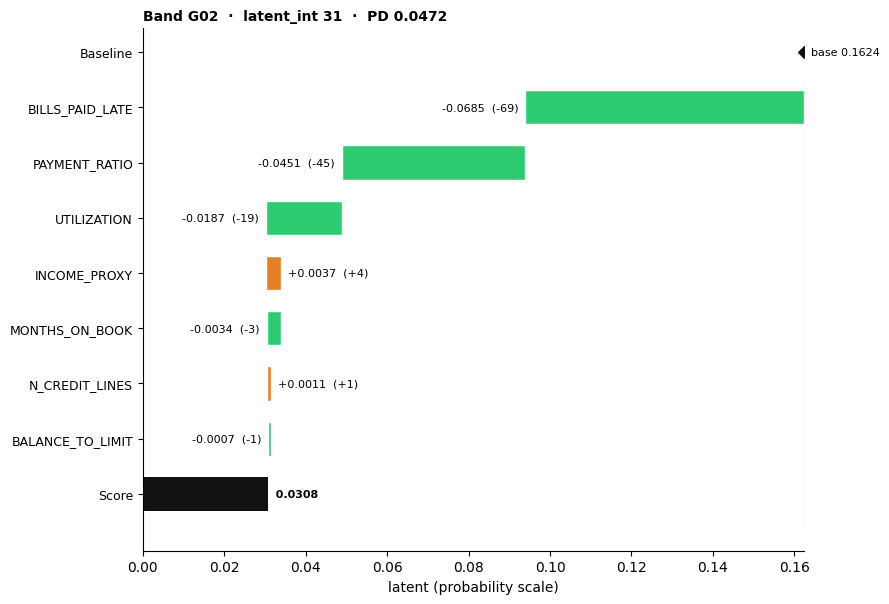

In [9]:
import matplotlib.pyplot as plt
from compileml.viz import waterfall, decision_drivers

fig, _ = waterfall(full)
plt.show()

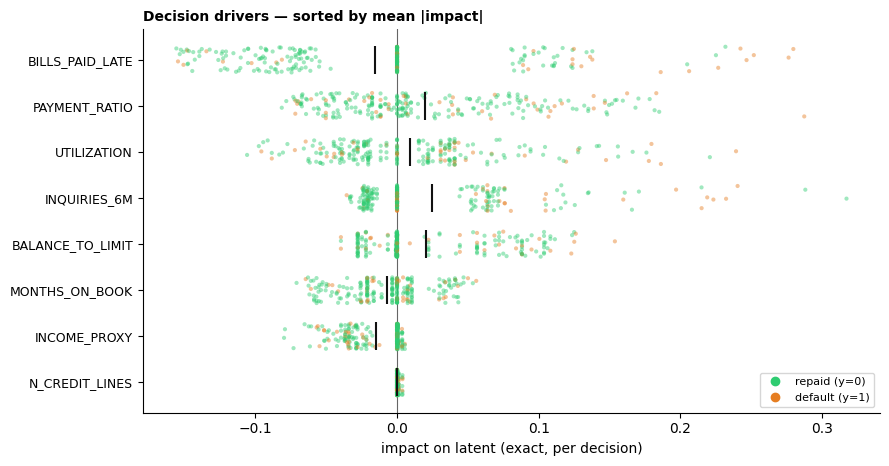

In [10]:
# Population view on a 250-row sample (explain=True is O(p^2) per row: sample, don't sweep).
sample_rows = X_test[:250]
sample = [decide(loaded, [float(v) for v in r], include_contributions=True) for r in sample_rows]
fig, _ = decision_drivers(sample, y=y_test[:250], top=8)
plt.show()

## 7. Validate — eight checks against the artifact itself

In [11]:
from compileml.validate import validate_artifact

report = validate_artifact(
    "decision.json",
    X_val=X_test[:4000], y_val=y_test[:4000],
    model=whitebox, latent_train=latent_train,
    require_full_reason_coverage=True,
)
for name, chk in report["checks"].items():
    print(f"  [{'PASS' if chk['pass'] else 'FAIL'}] {name}")
print("all_pass =", report["all_pass"])
assert report["all_pass"]

  [PASS] 1_integrity
  [PASS] 2_reconciliation
  [PASS] 3_fidelity
  [PASS] 4_band_properties
  [PASS] 5_semantic_monotonicity
  [PASS] 6_churn_baseline
  [PASS] 7_explainability_stability
  [PASS] 8_reason_coverage
all_pass = True


## Next

- `02_deploy_sql_cobol.ipynb` — the same artifact as a SQL query and a COBOL program
- `03_governance.ipynb` — tamper refusal, zero-churn recalibration, certified bands
- CLI equivalents: `compileml compile / score / validate / export`